# Tarea 3: Bootstrap


## Parte 1. La correlación

Correlacion observada: 0.776
SE bootstrap: 0.130
IC 95 %: [0.459, 0.965]


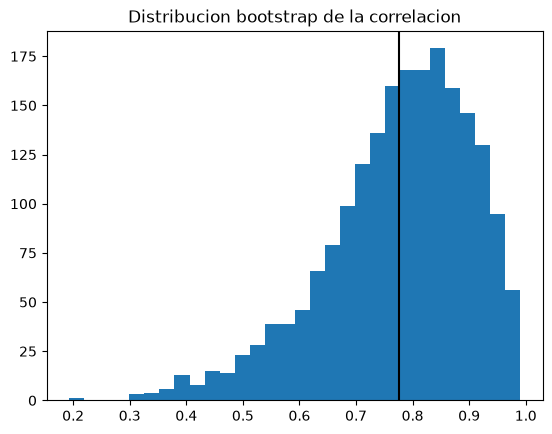

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(2024) # semilla: resultados reproducibles

LSAT = np.array([576,635,558,578,666,580,555,661,651,605,653,575,545,572,594], float)
GPA = np.array ([3.39,3.30,2.81,3.03,3.44,3.07,3.00,3.43,3.36,3.13,3.12,2.74,2.76,2.88,2.96])

r_obs = np.corrcoef(LSAT, GPA)[0, 1]
print(f"Correlacion observada: {r_obs:.3f}") # ~ 0.776

# Bootstrap: lo unico que van a completar ustedes es UNA linea
B = 2000
reps = np.empty(B)

for b in range(B):
    idx = rng.integers(low=0, high=len(LSAT), size=len(LSAT))
    reps[b] = np.corrcoef(LSAT[idx], GPA[idx])[0, 1]

se = reps.std(ddof=1)
ic = np.percentile(reps, [2.5, 97.5]) # intervalo por metodo percentil
print(f"SE bootstrap: {se:.3f}") # ~ 0.13
print(f"IC 95 %: [{ic[0]:.3f}, {ic[1]:.3f}]")

plt.hist(reps, bins=30)
plt.axvline(r_obs, color="k")
plt.title("Distribucion bootstrap de la correlacion")
plt.show()

**Pregunta 1.**
Miren su histograma. La distribución bootstrap sale sesgada hacia la izquierda (con una cola larga hacia abajo). Den una razón intuitiva: la correlación no puede pasar de 1, y la observada (≈ 0.78) ya está cerca de ese techo. ¿Cómo afecta eso a la forma de la distribución? Dos o tres líneas bastan

**Respuesta:**
La forma de la distribución se ve afectada por las limitaciones de la correlación. Como `r_obs` está dentro del intervalo $(-1, 1)$ y su valor es $≈ 0.784$ ya ocupa gran parte del espacio disponible hacia arriba, por lo que las réplicas bootstrap tienen poco margen para crecer antes de toparse con el techo en $1.0$. Por esta razón se puede ver un corte abrupto en esta sección, pues no puede superarlo. En cambio, el resto de las réplicas, pueden utilizar el resto del intervalo hacia abajo (desde $0.78$ hasta $-1$), y ese espacio más amplio permite que unas réplicas se dispersen con correlaciones mucho más bajas. Por eso la distribución se acumula contra el techo y deja una cola larga hacia la izquierda.
Es importante mencionar para este análisis que, aunque la correlación está definida en el intervalo $(-1, 1)$, en este problema la distribución bootstrap ocupa solo la región positiva, porque LSAT y GPA tienen una relación claramente positiva. 


## Parte 2: Un estadístico sin fórmula

Mediana observada: 12.00
SE bootstrap: 1.023
IC 95 %: [10.300, 13.800]


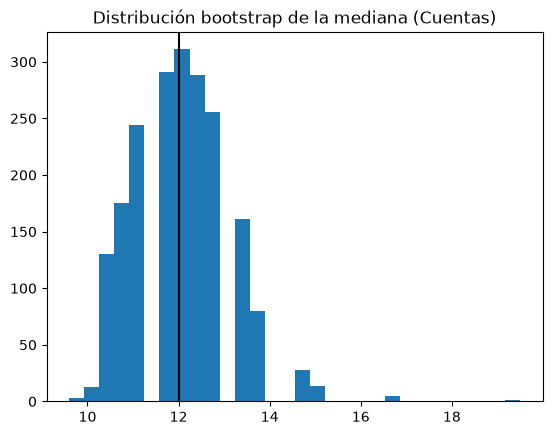

In [2]:
cuentas = np.array(
    [10.3, 12.5, 8.7, 15.2, 9.9, 21.4, 11.1, 13.8, 7.5, 18.0,
    9.2, 14.6, 10.8, 25.9, 12.0, 8.1, 16.7, 11.9, 10.0, 13.3,
    9.6, 19.5, 12.8, 10.5, 34.2]
)

med_obs = np.median(cuentas)
print(f"Mediana observada: {med_obs:.2f}")

# Su tarea: repliquen la logica de la Parte 1, pero para la MEDIANA.
# 1) muestreen con reemplazo 2) calculen np.median 3) SE e IC percentil 95 %

B2 = 2000
boot_medianas = np.empty(B2)

for b in range(B2):
    idx = rng.integers(low=0, high=len(cuentas), size=len(cuentas))
    boot_medianas[b] = np.median(cuentas[idx])


se2 = boot_medianas.std(ddof=1)
ic2 = np.percentile(boot_medianas, [2.5, 97.5]) # intervalo por metodo percentil
print(f"SE bootstrap: {se2:.3f}")
print(f"IC 95 %: [{ic2[0]:.3f}, {ic2[1]:.3f}]")

plt.hist(boot_medianas, bins=30)
plt.axvline(med_obs, color="k")
plt.title("Distribución bootstrap de la mediana (Cuentas)")
plt.show()

**Pregunta 2.**
Reporten la mediana observada, el SE bootstrap y el intervalo del 95 %. Luego
expliquen en una o dos líneas por qué la mediana es un buen ejemplo para el bootstrap: ¿por qué no es tan directo escribir su error estándar “a mano” como el de la media? (Pista: la fórmula clásica de la mediana depende de la densidad de los datos justo en el centro, algo que no observamos directamente)

**Respuesta:**
Los valores obtenidos fueron de $12.00$ para la mediana observada, $1.023$ para el SE bootstrap y $[10.300, 14.600]$ para el intervalo del 95%. 

Para la media, el error estándar se puede calcular a mano de forma directa porque solo depende de qué tan dispersos están los datos en general. Para la mediana no es tan simple, pues su error estándar depende de qué tan concentrados están los datos justo en el centro de la distribución (dado un conjunto de datos ordenado), y eso no se puede leer directamente de los datos. Por eso el bootstrap resulta útil para este caso, ya que remuestrea y obtiene la distribución de la mediana sin necesidad de calcular esa concentración a mano.


## Parte 3: El bootstrap no es magia (demo corta)

Maximo observado: 0.996
Fraccion de remuestreos con el MISMO maximo: 0.64


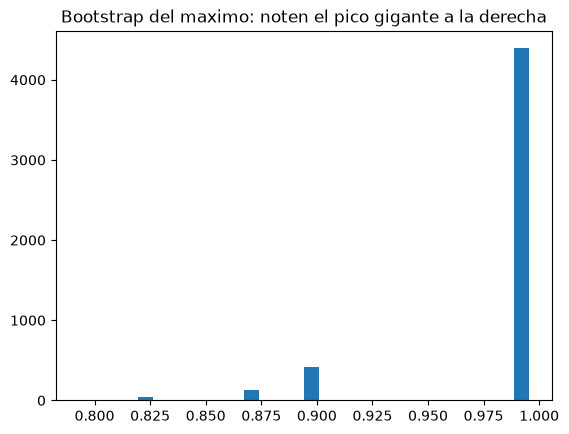

In [3]:
rng = np.random.default_rng(7)
muestra = rng.uniform(0, 1.0, size=20) # theta verdadero = 1.0
max_obs = muestra.max()

# Bootstrap del maximo
B = 5000
maxs = np.array([rng.choice(muestra, size=20, replace=True).max() for _ in range(B)])
frac_igual = np.mean(maxs == max_obs)

print(f"Maximo observado: {max_obs:.3f}")
print(f"Fraccion de remuestreos con el MISMO maximo: {frac_igual:.2f}") # ~ 0.63

plt.hist(maxs, bins=30)
plt.title("Bootstrap del maximo: noten el pico gigante a la derecha")
plt.show()

**Pregunta 3**. Van a ver que alrededor del 63 % de los remuestreos dan exactamente el mismo máximo, así que la distribución bootstrap se amontona en un solo punto en vez de ser suave. Expliquen en dos o tres líneas por qué pasa esto. Pista sencilla: una muestra bootstrap solo puede contener datos que ya estaban; nunca puede superar el máximo observado. Entonces el bootstrap no logra imaginar valores por encima de lo que vieron, y para estimar un tope eso es fatal.

**Respuesta:** Una muestra bootstrap solo puede contener valores que ya estaban dentro de la muestra original, no puede producir datos que no hayan aparecido previamente en la muestra, incluyendo el valor máximo. Esto significa que, a la hora de realizar los remuestreos, el máximo bootstrap es igual al máximo original siempre que ese valor haya sido seleccionado (64% según el código). Por ende, en este caso, la distribución bootstrap se amontona en un solo punto, pues este no puede inventar valores por encima del máximo que vio en la muestra y para estimar un tope esa limitación es significativa. No es un fallo del método ni del analista, sino una consecuencia de que el máximo depende de un solo dato extremo.


## Reflexión final
**1. En una frase: ¿qué le permite hacer el bootstrap que una fórmula de error estándar no siempre puede?**

El bootstrap permite estimar la variabilidad de cualquier estadístico a partir de una sola muestra. Concretamente, utiliza esa única muestra para reproducirla de manera aleatoria con el fin de aproximar su distribución y con ello lograr evaluar en cada caso nuevo (muestra bootstrap) la confiabilidad del estadístico.


**2. Después de la Parte 3, ¿en qué tipo de estadísticos no confiarían ciegamente en el bootstrap?**

No confiaría ciegamente en el bootstrap para estadísticos que dependen de valores extremos, como el máximo, el mínimo o cuantiles con valores muy diferentes. Concretamente, pude observar que el bootstrap nunca puede generar valores por encima del máximo observado, lo que provoca que la distribución se amontone en un punto y no refleja la incertidumbre real del estadístico. En cambio, para estadísticos como la media, la mediana o la correlación (sin extremos), el bootstrap funciona bien.
